In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.font_manager as fm

# 한글 폰트 설정
!apt-get install -y fonts-nanum > /dev/null 2>&1
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family=fm.FontProperties(fname=font_path).get_name())
plt.rcParams['axes.unicode_minus'] = False

In [9]:
# 데이터 로드 및 시계열 인덱스 변환
flights = sns.load_dataset('flights')
print(flights.shape)
flights.head()

(144, 3)


,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [10]:
# year + month → DatetimeIndex 로 변환
flights['date'] = pd.to_datetime(flights['year'].astype(str) + '-' + flights['month'].astype(str))
ts = flights.set_index('date')['passengers']
print(ts.head())

date
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Name: passengers, dtype: int64


/tmp/ipykernel_21474/50797109.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  flights['date'] = pd.to_datetime(flights['year'].astype(str) + '-' + flights['month'].astype(str))


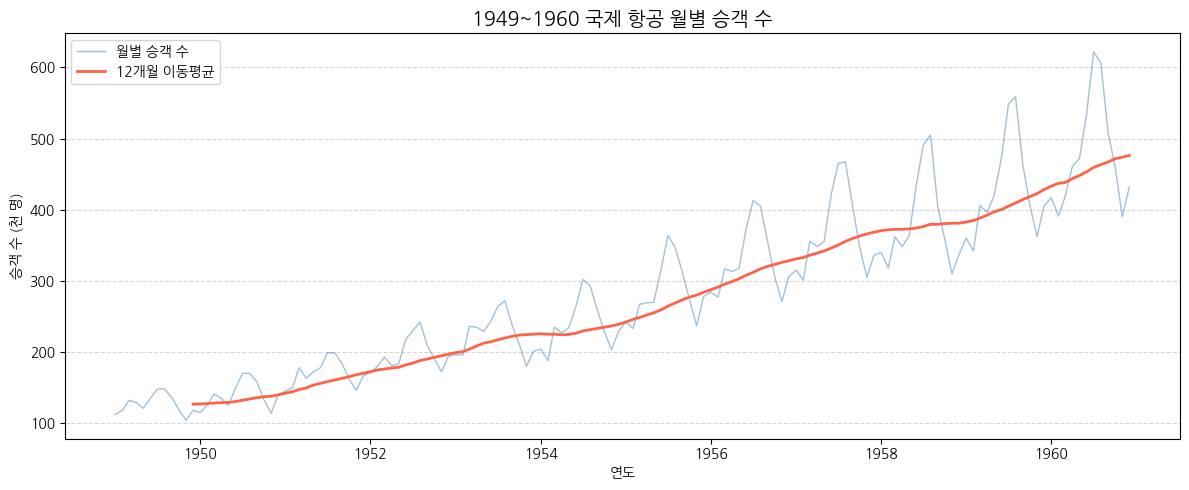

In [11]:
rolling = ts.rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ts.index, ts.values, color='steelblue', alpha=0.5, linewidth=1, label='월별 승객 수')
ax.plot(rolling.index, rolling.values, color='tomato', linewidth=2, label='12개월 이동평균')

ax.set_title('1949~1960 국제 항공 월별 승객 수', fontsize=14)
ax.set_xlabel('연도')
ax.set_ylabel('승객 수 (천 명)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

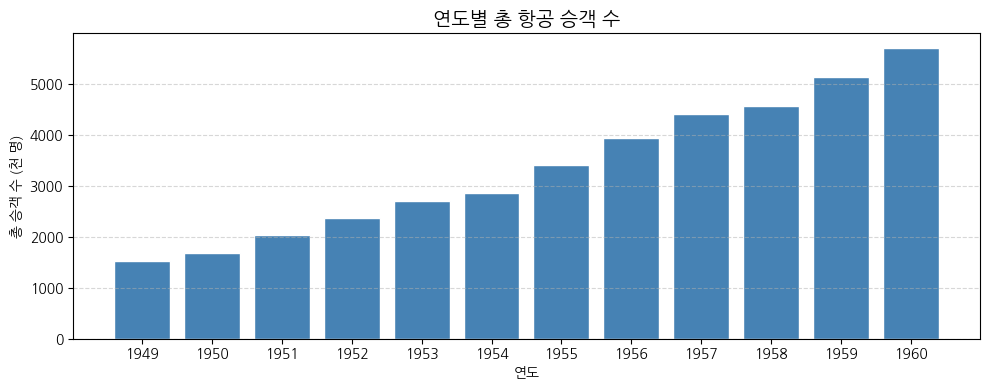

In [12]:
yearly = ts.resample('YE').sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(yearly.index.year, yearly.values, color='steelblue', edgecolor='white')

ax.set_title('연도별 총 항공 승객 수', fontsize=14)
ax.set_xlabel('연도')
ax.set_ylabel('총 승객 수 (천 명)')
ax.set_xticks(yearly.index.year)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()